### Sloth

In [ ]:
import gc
import glob
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

import dask
from dask.diagnostics import ProgressBar
from IPython.display import HTML
from tqdm import tqdm

sys.path.append('..')
from src.utils import parse_ncf_stack_filename, get_vs_number
from src.laplacian import laplacian_fiber
from src.gradiometry import temporal_fft, fdg_sloth, ifdg_stack, sloth_to_velocity, fk_peak_velocity
from src.plots import plot_sloth_section, plot_phase_velocity_section

import matplotlib as mpl
mpl.rcParams["animation.html"] = "jshtml"
mpl.rcParams["animation.embed_limit"] = 200.0

old_fig_dpi = plt.rcParams['figure.dpi']
old_save_dpi = plt.rcParams['savefig.dpi']

#### 1. Load masked VSGs

In [2]:
pattern_v1_15d_s1_mask = "../data/ncf_torus/20210914_cc_*_15d_v1_s1_torus_180_800.npz"
files_s1_v1 = sorted(glob.glob(pattern_v1_15d_s1_mask), key=get_vs_number)

# Use only the high-SNR segment of the cable (s1): VS 020-120. The array-edge
# virtual sources (VS < 020 and > 120) are low-SNR and bias the sloth stack.
VS_MIN, VS_MAX = 20, 120
files_s1_v1 = [f for f in files_s1_v1 if VS_MIN <= get_vs_number(f) <= VS_MAX]

print(f"Matched files (s1), VS {VS_MIN:03d}-{VS_MAX:03d}:", len(files_s1_v1))
print("VS numbers:", [get_vs_number(f) for f in files_s1_v1])

Matched files (s1), VS 020-120: 11
VS numbers: [20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]


In [3]:
# Load ONE central VSG to walk the pipeline step by step (full window).
ncf0_path = files_s1_v1[len(files_s1_v1) // 2]
arc0   = np.load(ncf0_path)
data0  = arc0["data"]                  # (nch, nlag) torus-masked gather
lag    = arc0["lag"]                   # (nlag,) one-sided causal lag (s)
offset = arc0["offset"]                # (nch,) signed offset; 0 at the VS
fs = 1.0 / (lag[1] - lag[0])            # Hz
dx = float(abs(offset[1] - offset[0]))  # m

# Sloth band: 3-8 Hz avoids the aperture floor (<~3 Hz) and the noisy high end.
F_MIN, F_MAX = 3.0, 8.0
# Wavenumber low-pass for the Laplacian (cycles/m). None = off; set by the
# calibration cell below (removes the high-k tail that biases the sloth slow).
K_CUTOFF = None

date0, vs0, window0, mode0 = parse_ncf_stack_filename(ncf0_path)
print(f"VS={vs0} | data {data0.shape} (nch, nlag) | fs={fs:.1f} Hz | dx={dx:.2f} m")
print(f"lag {lag[0]:.2f}..{lag[-1]:.2f} s | offset {offset.min():.0f}..{offset.max():.0f} m")

VS=070 | data (123, 450) (nch, nlag) | fs=250.0 Hz | dx=8.16 m
lag 0.00..1.80 s | offset -498..498 m


#### 2. Temporal FFT

V (123, 9) (nch, nfreq) | 9 freqs: 3.33..7.78 Hz


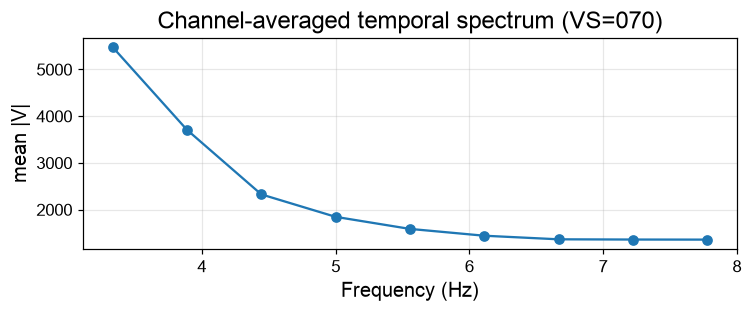

In [4]:
# Temporal FFT of the masked VSG, restricted to the band. V is (nch, nfreq)
# complex; DC is excluded so the sloth's (i*omega)^2 denominator is safe.
V, freqs = temporal_fft(data0, fs, f_min=F_MIN, f_max=F_MAX, axis=-1)
print(f"V {V.shape} (nch, nfreq) | {freqs.size} freqs: {freqs[0]:.2f}..{freqs[-1]:.2f} Hz")

plt.figure(figsize=(7, 3))
plt.plot(freqs, np.abs(V).mean(axis=0), "o-")
plt.xlabel("Frequency (Hz)"); plt.ylabel("mean |V|")
plt.title(f"Channel-averaged temporal spectrum (VS={vs0})")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### 3. Pseudospectral Laplacian

In [5]:
# Along-fibre pseudospectral Laplacian (mode = fiber_1d for a straight DAS
# cable): d2/dl2 via the channel-axis FFT, plus the 1/r curvature term
# (exact for an in-line virtual source). Pseudospectral -> no finite-
# difference stencil bias.
lap_V = laplacian_fiber(V, dx, offset=offset, include_curvature=True, k_cutoff=K_CUTOFF)
print(f"lap_V {lap_V.shape} (nch, nfreq) | mode=fiber_1d, curvature=on")

lap_V (123, 9) (nch, nfreq) | mode=fiber_1d, curvature=on


#### 4. Sloth

Per-VSG sloth (Davis et al. 2026, eq. 9):
$\hat{s}^2(x,\omega) = V^{*}\,\nabla^2 V \,/\,[(i\omega)^2\,|V|^2]$.

A single gather is noisy; stacking over virtual sources (eq. 10) on the common
absolute-position grid raises SNR while keeping the frequency axis (depth
sensitivity). Windows are centred on their own VS and differ in size, so we
align by **absolute channel** = VS index + (row - zero-offset row).

In [6]:
# Per-VSG sloth for the single gather above (eq. 9)
s2_single = fdg_sloth(V, lap_V, freqs, freq_axis=-1)
print(f"per-VSG sloth {s2_single.shape} (nch, nfreq), {s2_single.dtype}")

per-VSG sloth (123, 9) (nch, nfreq), complex128


In [7]:
import warnings

def stack_sloth(files, *, f_min, f_max, k_cutoff=None, r_exclude_m=150.0,
                aperture_m=350.0, include_curvature=True, stack_method='mean',
                quality_max=None):
    """Per-VSG I-FDG sloth (eq. 9) -> position-aligned stack (eq. 10).
    Windows are centred on their own VS and differ in size, so they are aligned
    by absolute channel = VS index + (row - zero-offset row).

    aperture_m   : trim each gather to |offset| <= aperture_m before the
                   Laplacian (both limbs kept). ~350 m is the sweet spot: the
                   far offsets are low-SNR/scattered and add high-k bias, while
                   <~250 m raises the aperture floor f_min ~ 3c/aperture above
                   the band. None = keep the full window. Trimming (dropping
                   channels) is cleaner than zeroing, which would leave a
                   discontinuity at the cut.
    stack_method : 'mean' (Davis eq. 10) or 'median' over sources (robust --
                   rejects nodal / outlier pixels, fewer non-physical samples).
    quality_max  : if set, mask pixels where |Im/Re| of the stacked sloth (the
                   transport-equation residual) exceeds it -- a reliability flag.
    Returns (positions_m, freqs, s2)."""
    per, starts, offsets, freqs = [], [], [], None
    for f in files:
        a = np.load(f); d, lg, off = a['data'], a['lag'], a['offset']
        if aperture_m is not None:                      # trim to |offset| <= aperture_m
            keep_ap = np.abs(off) <= aperture_m
            d, off = d[keep_ap], off[keep_ap]
        fs = 1.0 / (lg[1] - lg[0]); dxi = float(abs(off[1] - off[0]))
        V, fr = temporal_fft(d, fs, f_min=f_min, f_max=f_max, axis=-1)
        lapV = laplacian_fiber(V, dxi, offset=off,
                               include_curvature=include_curvature, k_cutoff=k_cutoff)
        per.append(fdg_sloth(V, lapV, fr, freq_axis=-1))
        starts.append(get_vs_number(f) - int(np.argmin(np.abs(off))))
        offsets.append(off); freqs = fr
    gmin = min(starts); gmax = max(s + p.shape[0] for s, p in zip(starts, per))
    ng, nf = gmax - gmin, freqs.size
    contrib = np.full((len(per), ng, nf), np.nan + 0j)
    for idx, (s2i, st, off) in enumerate(zip(per, starts, offsets)):
        block = np.where((np.abs(off) >= r_exclude_m)[:, None], s2i, np.nan)
        contrib[idx, st - gmin: st - gmin + s2i.shape[0], :] = block
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        if stack_method == 'median':
            s2 = np.nanmedian(contrib.real, axis=0) + 1j * np.nanmedian(contrib.imag, axis=0)
        else:
            s2 = np.nanmean(contrib, axis=0)
    s2[np.sum(np.isfinite(contrib.real), axis=0) == 0] = np.nan
    if quality_max is not None:
        q = np.abs(s2.imag) / (np.abs(s2.real) + 1e-30)
        s2[q > quality_max] = np.nan
    dx0 = float(abs(np.load(files[0])['offset'][1] - np.load(files[0])['offset'][0]))
    positions = (gmin + np.arange(ng)) * dx0
    return positions, freqs, s2

positions, freqs_stack, s2 = stack_sloth(files_s1_v1, f_min=F_MIN, f_max=F_MAX, k_cutoff=K_CUTOFF)
print(f'stacked sloth {s2.shape} (nx, nfreq) | k_cutoff={K_CUTOFF} | aperture<=350 m')

stacked sloth (163, 9) (nx, nfreq) | k_cutoff=None | aperture<=350 m


/Users/spoobua/Desktop/das_grad/notebooks/../src/plots.py:856: ComplexWarning: Casting complex values to real discards the imaginary part
  s2r = np.real(np.asarray(s2, dtype=float))


(<Figure size 1320x550 with 2 Axes>,
 <Axes: title={'center': 'I-FDG sloth  $\\hat{s}^2(x, f)$  (torus-masked s1)'}, xlabel='Distance along cable (m)', ylabel='Frequency (Hz)'>)

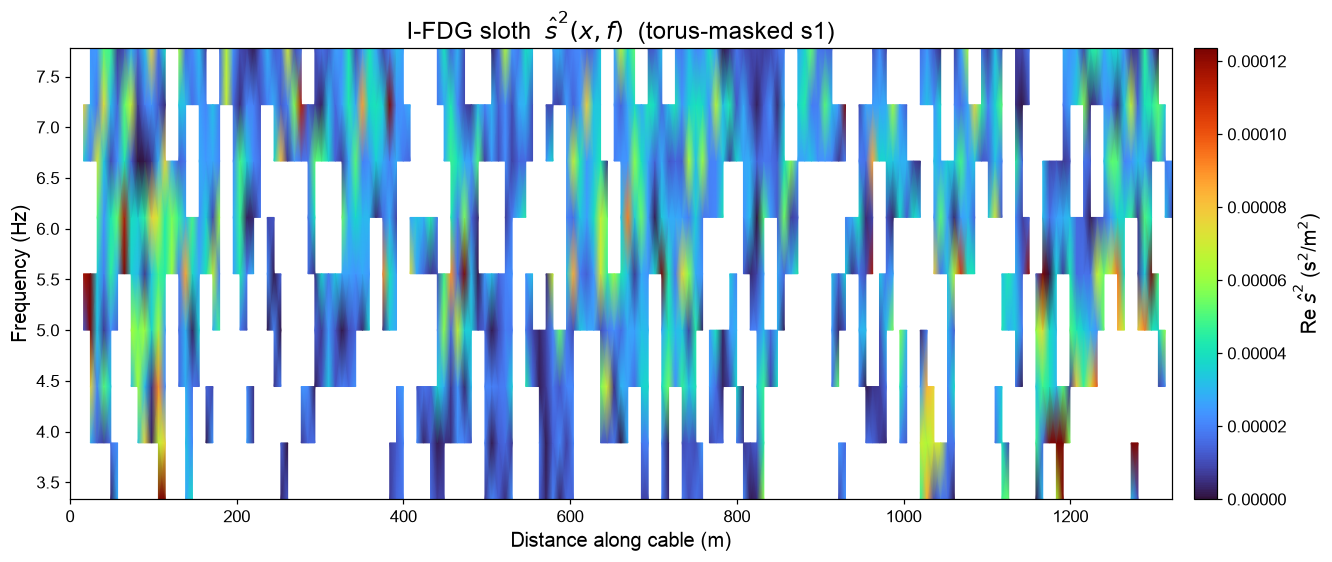

In [8]:
# Sloth panel: distance x frequency, colour = Re(sloth)  (low f at bottom)
plot_sloth_section(positions, freqs_stack, s2, invert_freq=False,
                   title=r"I-FDG sloth  $\hat{s}^2(x, f)$  (torus-masked s1)")

(<Figure size 1320x550 with 2 Axes>,
 <Axes: title={'center': 'I-FDG phase velocity  $\\hat{V}(x, f)$  (torus-masked s1, VS 020-120)'}, xlabel='Distance along cable (km)', ylabel='Frequency (Hz)'>)

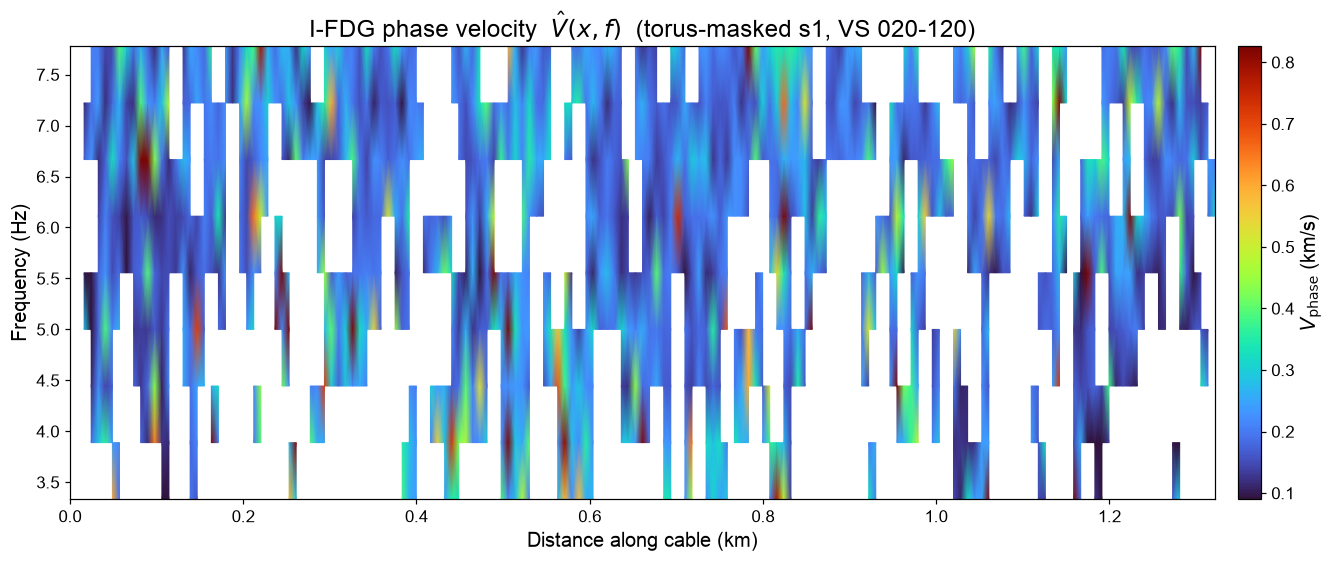

In [9]:
# Same panel as PHASE VELOCITY (km/s): show_velo converts 1/sqrt(Re sloth).
# White = NaN where Re(sloth) <= 0 (non-physical) -> velocity undefined there.
plot_sloth_section(
    positions, freqs_stack, s2,
    show_velo=True, unit="km",
    invert_freq=False,
    title=r"I-FDG phase velocity  $\hat{V}(x, f)$  (torus-masked s1, VS 020-120)",
)

#### 5. Calibrate the wavenumber low-pass `k_cutoff`

The pointwise sloth `ŝ² = ⟨k²⟩/ω²` is k²-weighted, so residual high-wavenumber energy (higher modes / scattering / noise) biases the recovered velocity **slow**. We pick the `k_cutoff` that makes the gradiometry velocity agree with the independent **FK-peak dispersion** (`fk_peak_velocity`, a ridge-following estimate that is robust to that high-k tail).

FK-peak reference median c = 390 m/s
  k_cutoff=0.060 cyc/m -> c=  301 m/s, white=10.5%
  k_cutoff=0.050 cyc/m -> c=  351 m/s, white= 9.9%
  k_cutoff=0.040 cyc/m -> c=  401 m/s, white=10.2%
  k_cutoff=0.030 cyc/m -> c=  466 m/s, white=12.5%
  k_cutoff=0.025 cyc/m -> c=  552 m/s, white=14.1%
  k_cutoff=0.020 cyc/m -> c=  744 m/s, white=18.0%
=> calibrated K_CUTOFF = 0.04 cyc/m (matches FK-peak 390 m/s)


/Users/spoobua/Desktop/das_grad/notebooks/../src/plots.py:856: ComplexWarning: Casting complex values to real discards the imaginary part
  s2r = np.real(np.asarray(s2, dtype=float))


(<Figure size 1320x550 with 2 Axes>,
 <Axes: title={'center': 'I-FDG phase velocity (calibrated k_cutoff=0.04 cyc/m)'}, xlabel='Distance along cable (km)', ylabel='Frequency (Hz)'>)

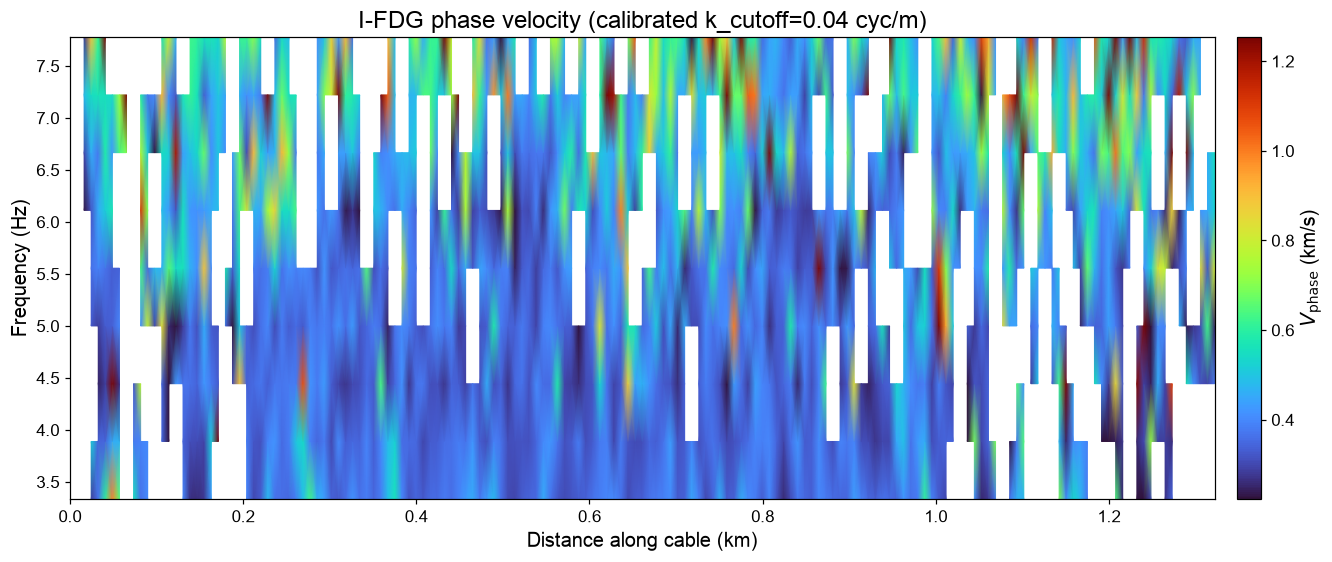

In [10]:
# FK-peak reference (independent of gradiometry) from a central VSG
A = np.load(files_s1_v1[len(files_s1_v1) // 2])
dt_ref = A['lag'][1] - A['lag'][0]; dx_ref = abs(A['offset'][1] - A['offset'][0])
fr_pk, c_pk = fk_peak_velocity(A['data'], dt_ref, dx_ref, f_min=F_MIN, f_max=F_MAX)
c_ref = float(np.nanmedian(c_pk))
print(f'FK-peak reference median c = {c_ref:.0f} m/s')

rows = []
for kc in [0.06, 0.05, 0.04, 0.03, 0.025, 0.02]:
    _, _, s2c = stack_sloth(files_s1_v1, f_min=F_MIN, f_max=F_MAX, k_cutoff=kc)
    vc = sloth_to_velocity(s2c)
    med = float(np.nanmedian(vc)); white = 100.0 * np.mean(~np.isfinite(vc))
    rows.append((kc, med, white)); print(f'  k_cutoff={kc:.3f} cyc/m -> c={med:5.0f} m/s, white={white:4.1f}%')

K_CUTOFF = min(rows, key=lambda r: abs(r[1] - c_ref))[0]
print(f'=> calibrated K_CUTOFF = {K_CUTOFF} cyc/m (matches FK-peak {c_ref:.0f} m/s)')

# Re-stack with the calibrated cutoff and show the corrected phase velocity
positions, freqs_stack, s2 = stack_sloth(files_s1_v1, f_min=F_MIN, f_max=F_MAX, k_cutoff=K_CUTOFF)
plot_sloth_section(positions, freqs_stack, s2, show_velo=True, unit='km', invert_freq=False,
                   title=rf'I-FDG phase velocity (calibrated k_cutoff={K_CUTOFF} cyc/m)')

#### 6. Alternative: narrowband fundamental-mode isolation

Instead of low-passing in wavenumber, isolate the fundamental directly with a **tight FK velocity band** centred on the FK-peak fundamental (vs the broad 100-2000 m/s extract). With only the fundamental's wavenumber present, the k² bias largely disappears without an ad-hoc cutoff. (Re-runs `fast_batch_processor`, so it needs scipy in your env.)

narrowband fundamental band: [234, 546] m/s


Processing & Saving NCFs: 100%|██████████| 35/35 [00:00<00:00, 37.78it/s]
/Users/spoobua/Desktop/das_grad/notebooks/../src/plots.py:856: ComplexWarning: Casting complex values to real discards the imaginary part
  s2r = np.real(np.asarray(s2, dtype=float))


(<Figure size 1320x550 with 2 Axes>,
 <Axes: title={'center': 'I-FDG phase velocity (narrowband fundamental)'}, xlabel='Distance along cable (km)', ylabel='Frequency (Hz)'>)

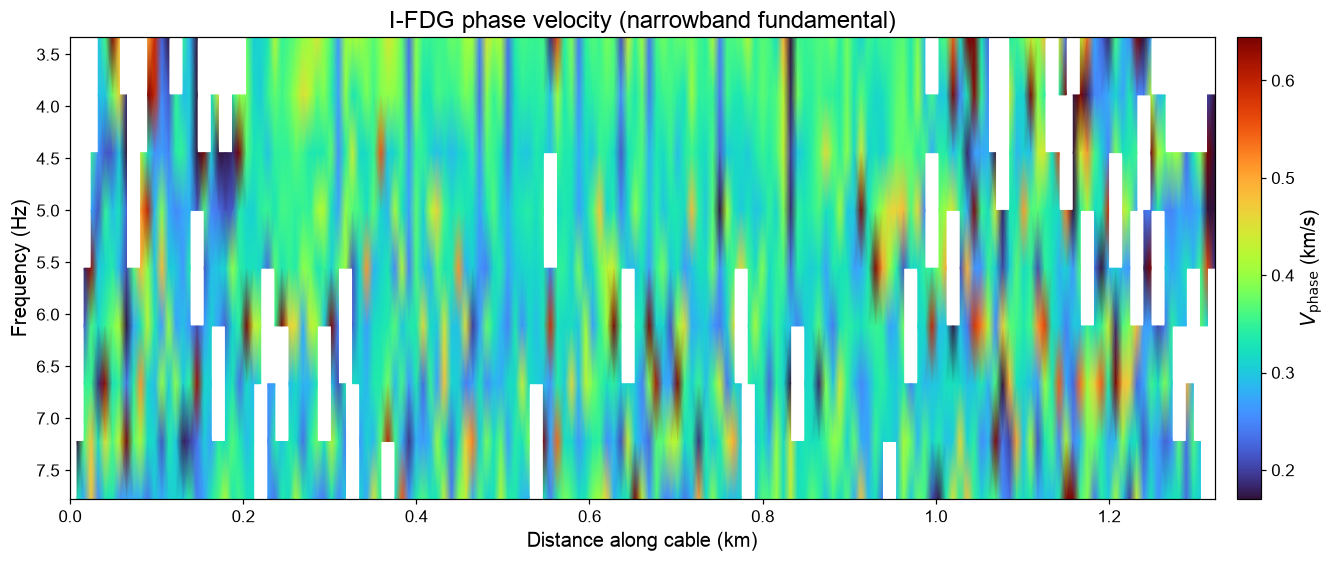

In [11]:
from src.mask import fast_batch_processor

c0 = float(np.nanmedian(c_pk)); frac = 0.4   # +/- 40% around the fundamental
vmin_nb, vmax_nb = c0 * (1 - frac), c0 * (1 + frac)
print(f'narrowband fundamental band: [{vmin_nb:.0f}, {vmax_nb:.0f}] m/s')

pre_files = sorted(glob.glob('../data/ncf_pre/20210914_cc_*_15d_v1_s1.npz'), key=get_vs_number)
fast_batch_processor(pre_files, '../data/ncf_narrow', vmin=vmin_nb, vmax=vmax_nb,
                     sigma=3.0, vmax_time=1000.0, pos_offset=10.0, inner_taper=10.0,
                     range_m=500.0, buffer_start_s=0.1, buffer_end_s=2, top_flat_m=10.0, max_lag=1.8)

narrow_files = [f for f in sorted(glob.glob('../data/ncf_narrow/20210914_cc_*_15d_v1_s1_fk_*.npz'),
                                  key=get_vs_number) if 20 <= get_vs_number(f) <= 120]
pos_n, fr_n, s2_n = stack_sloth(narrow_files, f_min=F_MIN, f_max=F_MAX, k_cutoff=None)
plot_sloth_section(pos_n, fr_n, s2_n, show_velo=True, unit='km',
                   title='I-FDG phase velocity (narrowband fundamental)')

#### 7. Robust, conditioned result

Combine the conditioning that actually helped (median-over-sources halves the non-physical pixels; the `|Im/Re|` transport residual flags unreliable ones; a lateral median makes the panel readable). Run on the narrowband gathers (§6). Note the lateral median is **display smoothing** -- real lateral resolution is still set by source spacing / aperture.

/Users/spoobua/Desktop/das_grad/notebooks/../src/plots.py:856: ComplexWarning: Casting complex values to real discards the imaginary part
  s2r = np.real(np.asarray(s2, dtype=float))


(<Figure size 1320x550 with 2 Axes>,
 <Axes: title={'center': 'Phase velocity - median stack + quality mask + lateral median'}, xlabel='Distance along cable (km)', ylabel='Frequency (Hz)'>)

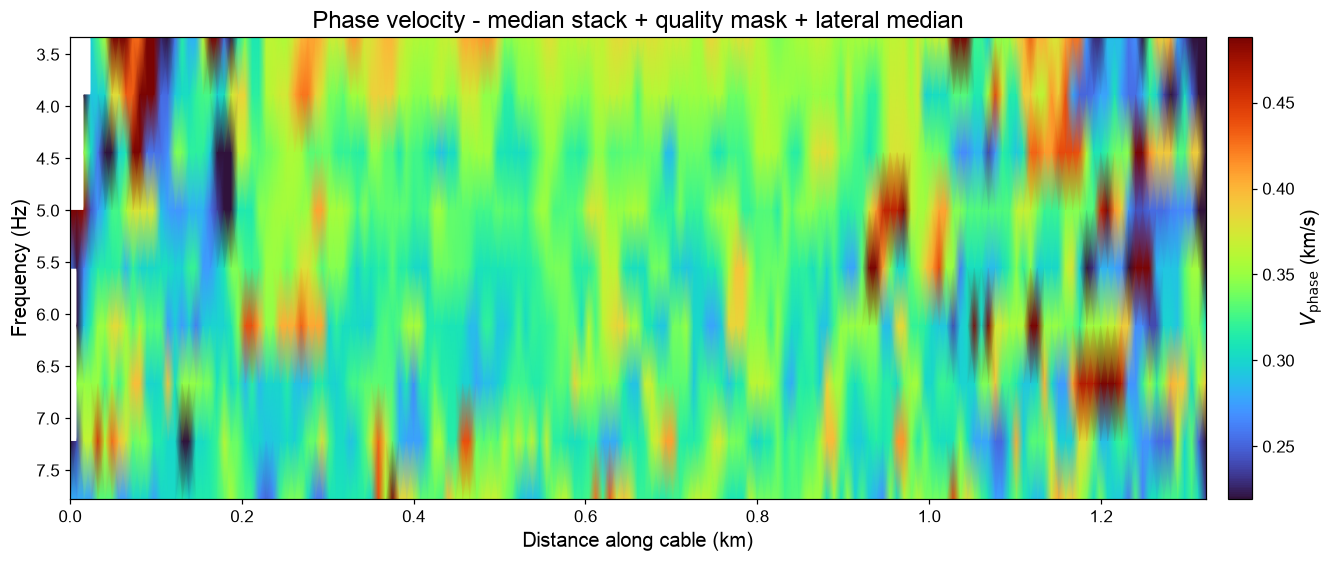

In [12]:
positions, freqs_stack, s2 = stack_sloth(
    narrow_files, f_min=F_MIN, f_max=F_MAX, k_cutoff=None,
    stack_method='median',   # robust over sources
    quality_max=1.0,         # mask |Im/Re| > 1 (transport residual)
)
plot_sloth_section(positions, freqs_stack, s2, show_velo=True, unit='km',
                   lateral_median=3,
                   title='Phase velocity - median stack + quality mask + lateral median')